In [ ]:
!apt-get install git-lfs
!git lfs install

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git-lfs is already the newest version (3.0.2-1ubuntu0.3).
0 upgraded, 0 newly installed, 0 to remove and 51 not upgraded.
Git LFS initialized.


In [ ]:
!git clone https://huggingface.co/datasets/doron333/change-detection-dataset


fatal: destination path 'change-detection-dataset' already exists and is not an empty directory.


In [ ]:
import os

dataset_path = "/content/change-detection-dataset"

print(os.listdir(dataset_path))

['README.md', 'GalaxEye_Technical_Assignment_v2.pdf', '.git', 'val.zip', 'test.zip', 'train.zip', '.gitattributes']


In [ ]:
import zipfile
import os

zip_path = "/content/change-detection-dataset/train.zip"
extract_path = "/content/train_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed")

Extraction completed


In [ ]:
import os

base = '/content/train_data/train'

pre_files    = sorted(os.listdir(f'{base}/pre-event'))
post_files   = sorted(os.listdir(f'{base}/post-event'))
target_files = sorted(os.listdir(f'{base}/target'))

print(f"Pre event files   : {len(pre_files)}")
print(f"Post event files  : {len(post_files)}")
print(f"Target files      : {len(target_files)}")

print(f"\nFirst few filenames:")
print(f"Pre    : {pre_files[:3]}")
print(f"Post   : {post_files[:3]}")
print(f"Target : {target_files[:3]}")

Pre event files   : 2781
Post event files  : 2781
Target files      : 2781

First few filenames:
Pre    : ['scene_01_000001_building_damage.tif', 'scene_01_000002_building_damage.tif', 'scene_01_000003_building_damage.tif']
Post   : ['scene_01_000001_building_damage.tif', 'scene_01_000002_building_damage.tif', 'scene_01_000003_building_damage.tif']
Target : ['scene_01_000001_building_damage.tif', 'scene_01_000002_building_damage.tif', 'scene_01_000003_building_damage.tif']


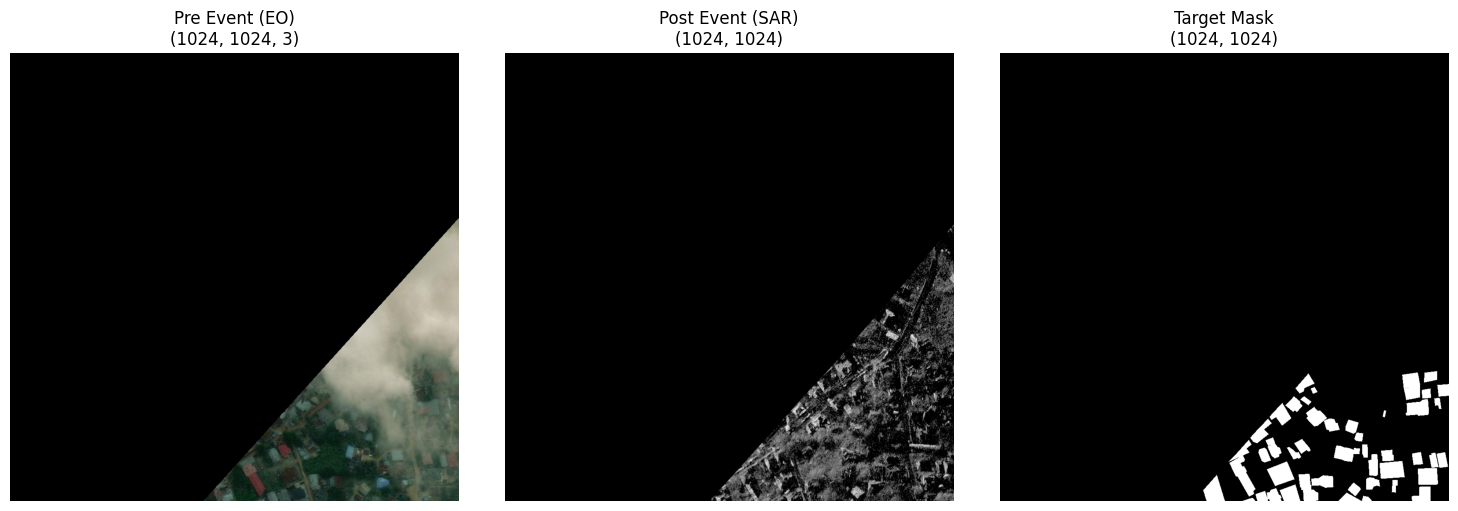

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

pre    = Image.open(f'{base}/pre-event/{pre_files[0]}')
post   = Image.open(f'{base}/post-event/{post_files[0]}')
target = Image.open(f'{base}/target/{target_files[0]}')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(pre)
axes[0].set_title(f'Pre Event (EO)\n{np.array(pre).shape}')
axes[0].axis('off')

axes[1].imshow(post, cmap='gray')
axes[1].set_title(f'Post Event (SAR)\n{np.array(post).shape}')
axes[1].axis('off')

axes[2].imshow(target, cmap='gray')
axes[2].set_title(f'Target Mask\n{np.array(target).shape}')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from PIL import Image
import os

base = '/content/train_data/train'
target_files = sorted(os.listdir(f'{base}/target'))

total_pixels   = 0
changed_pixels = 0

for i, fname in enumerate(target_files):
    mask = np.array(Image.open(f'{base}/target/{fname}'))

    # remap: 0,1 → 0 (no change), 2,3 → 1 (change)
    binary = np.where(mask >= 2, 1, 0)

    total_pixels   += binary.size
    changed_pixels += binary.sum()

    if i % 500 == 0:
        print(f"Processed {i}/{len(target_files)}...")

unchanged = total_pixels - changed_pixels
print(f"\nTotal pixels    : {total_pixels:,}")
print(f"Changed pixels  : {changed_pixels:,} ({100*changed_pixels/total_pixels:.2f}%)")
print(f"Unchanged pixels: {unchanged:,} ({100*unchanged/total_pixels:.2f}%)")
print(f"Imbalance ratio : 1 : {unchanged/changed_pixels:.1f}")

Processed 0/2781...
Processed 500/2781...
Processed 1000/2781...
Processed 1500/2781...
Processed 2000/2781...
Processed 2500/2781...

Total pixels    : 2,916,089,856
Changed pixels  : 45,769,150 (1.57%)
Unchanged pixels: 2,870,320,706 (98.43%)
Imbalance ratio : 1 : 62.7


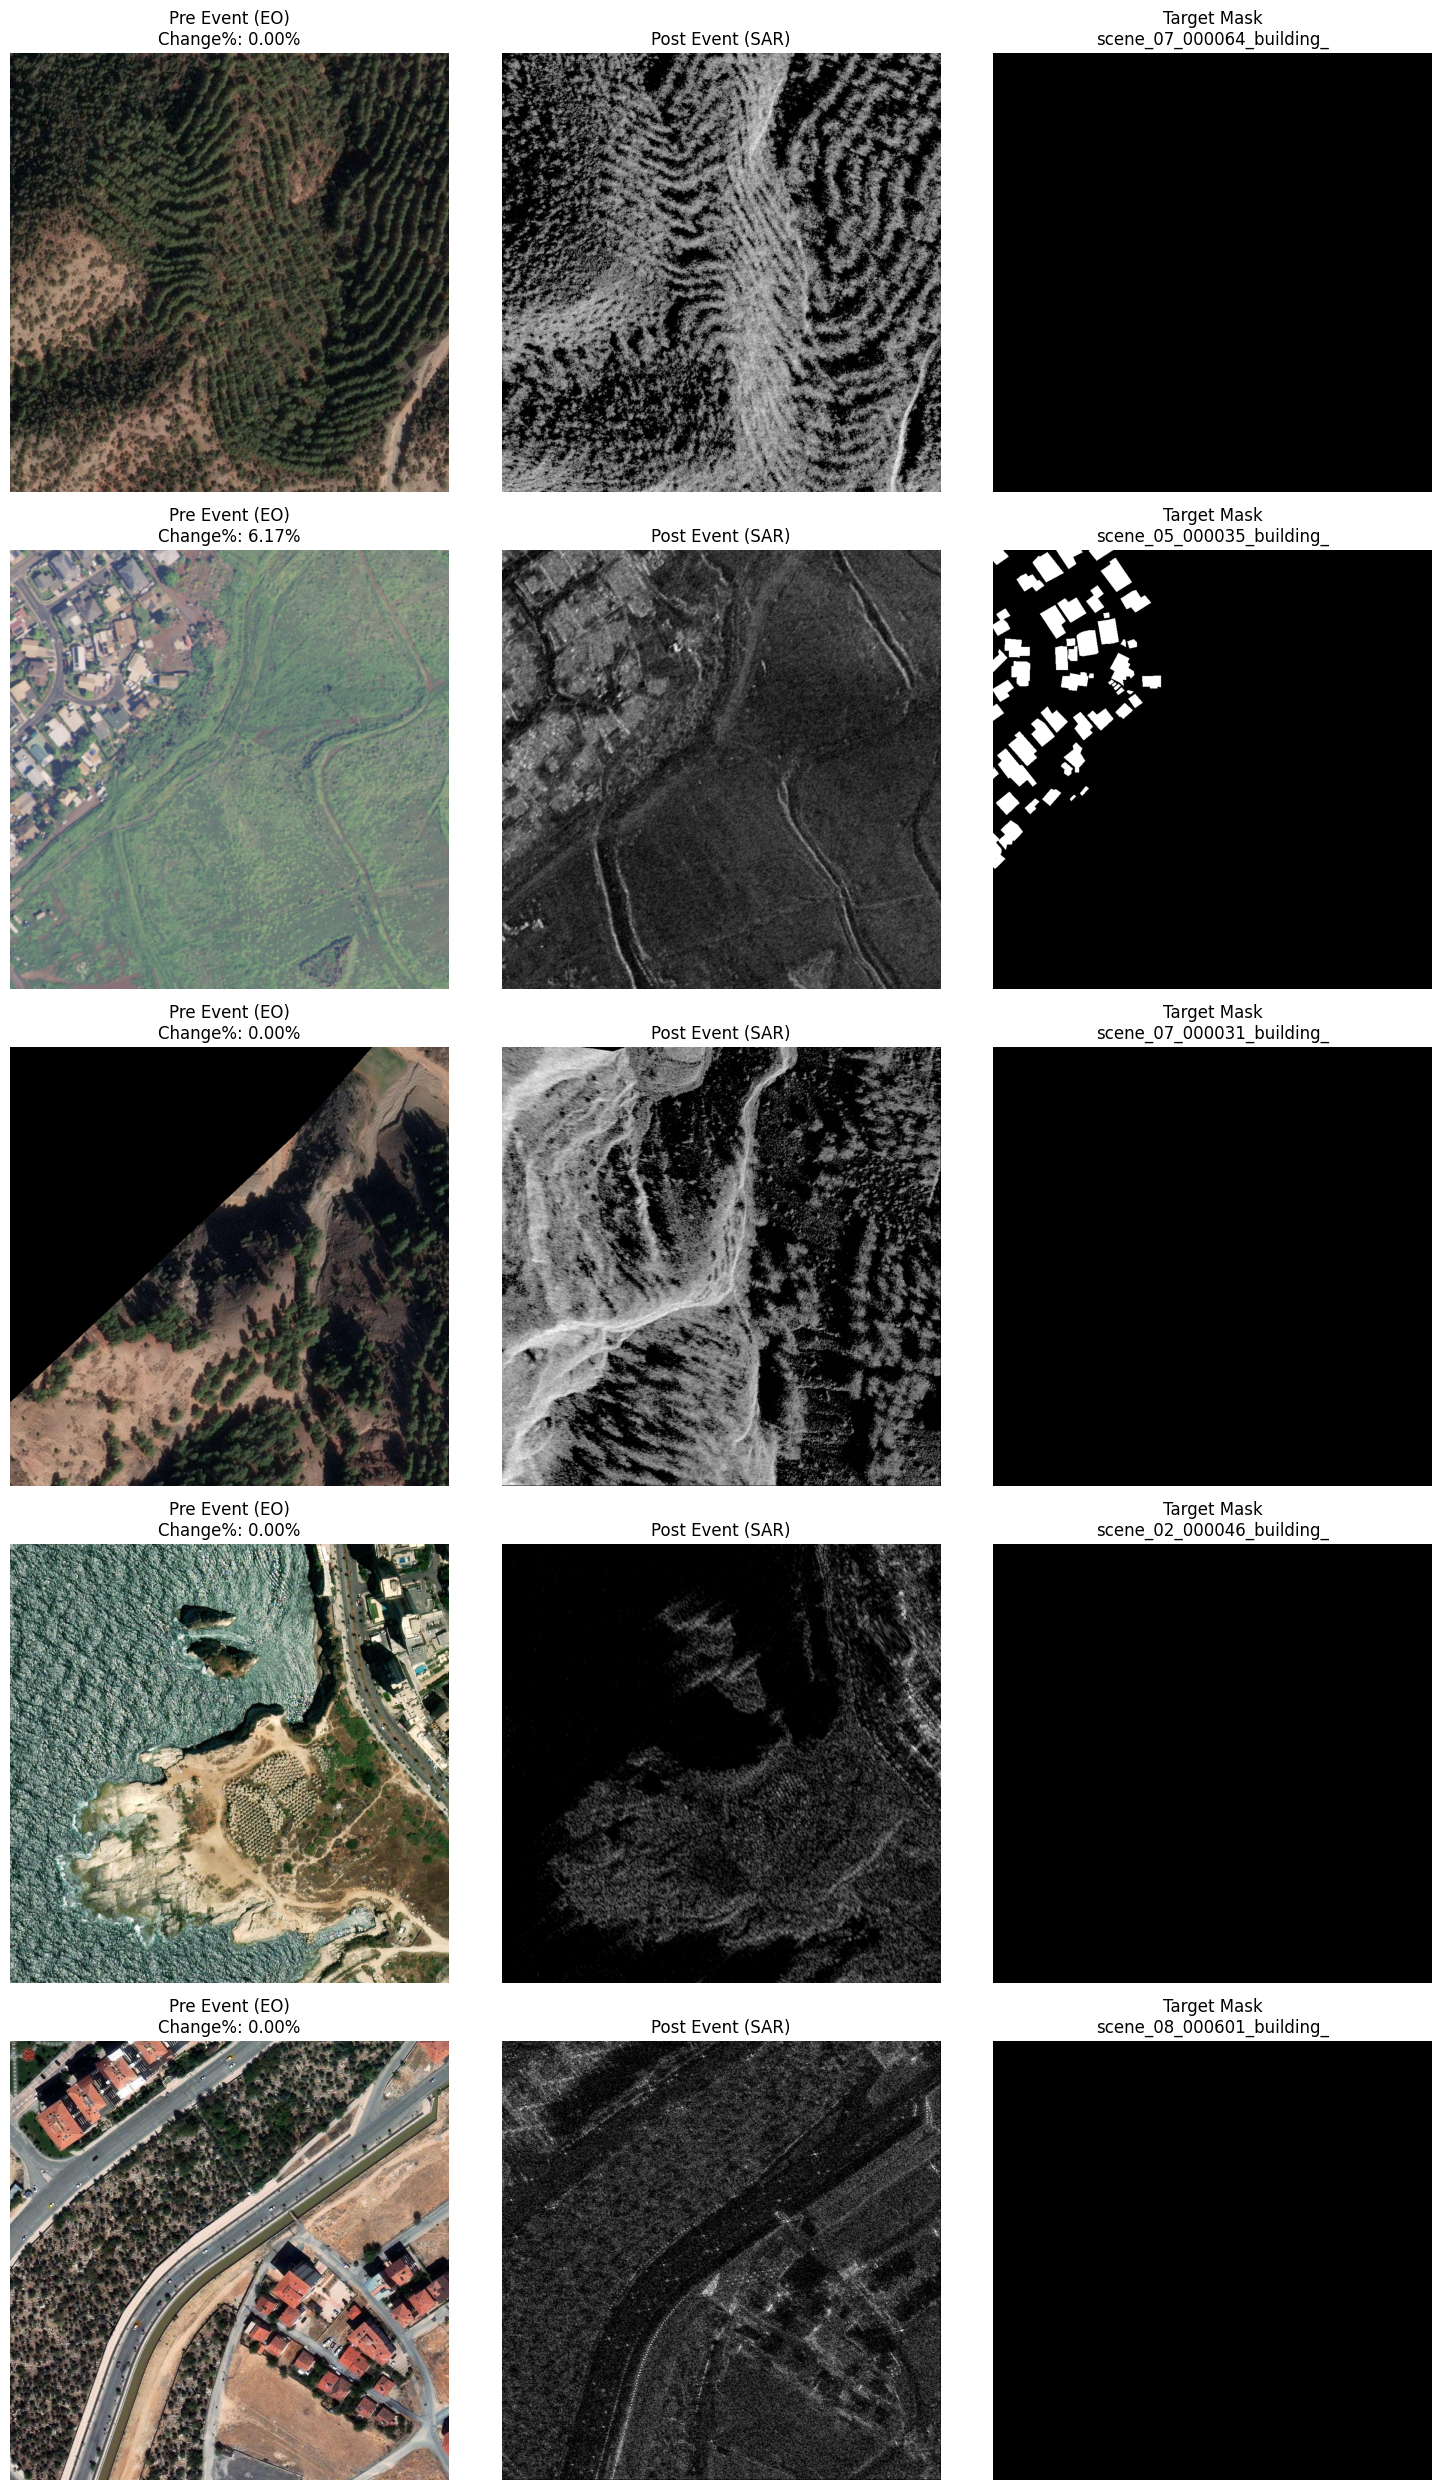

In [ ]:
import random
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os

base = '/content/train_data/train'
pre_files = sorted(os.listdir(f'{base}/pre-event'))

# pick 5 random samples
indices = random.sample(range(len(pre_files)), 5)

fig, axes = plt.subplots(5, 3, figsize=(15, 25))

for row, idx in enumerate(indices):
    fname = pre_files[idx]

    pre    = np.array(Image.open(f'{base}/pre-event/{fname}'))
    post   = np.array(Image.open(f'{base}/post-event/{fname}'))
    target = np.array(Image.open(f'{base}/target/{fname}'))

    # remap target
    binary = np.where(target >= 2, 1, 0)

    axes[row,0].imshow(pre)
    axes[row,0].set_title(f'Pre Event (EO)\nChange%: {100*binary.mean():.2f}%')
    axes[row,0].axis('off')

    axes[row,1].imshow(post, cmap='gray')
    axes[row,1].set_title('Post Event (SAR)')
    axes[row,1].axis('off')

    axes[row,2].imshow(binary, cmap='gray')
    axes[row,2].set_title(f'Target Mask\n{fname[:25]}')
    axes[row,2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from PIL import Image
import os

base = '/content/train_data/train'
pre_files = sorted(os.listdir(f'{base}/pre-event'))

# check first 5 samples
for i in range(5):
    fname = pre_files[i]

    pre    = np.array(Image.open(f'{base}/pre-event/{fname}'))
    post   = np.array(Image.open(f'{base}/post-event/{fname}'))
    target = np.array(Image.open(f'{base}/target/{fname}'))

    print(f"\n[{fname[:30]}]")
    print(f"  EO  - min:{pre.min():4d}  max:{pre.max():4d}  mean:{pre.mean():.1f}")
    print(f"  SAR - min:{post.min():4d}  max:{post.max():4d}  mean:{post.mean():.1f}")
    print(f"  Mask unique values: {np.unique(target)}")


[scene_01_000001_building_damag]
  EO  - min:   0  max: 218  mean:18.2
  SAR - min:   0  max: 238  mean:8.2
  Mask unique values: [0 1]

[scene_01_000002_building_damag]
  EO  - min:   0  max: 255  mean:84.3
  SAR - min:   0  max: 255  mean:41.6
  Mask unique values: [0 1]

[scene_01_000003_building_damag]
  EO  - min:   0  max: 255  mean:62.8
  SAR - min:   0  max: 235  mean:43.0
  Mask unique values: [0 1]

[scene_01_000004_building_damag]
  EO  - min:   0  max: 255  mean:34.6
  SAR - min:   0  max: 238  mean:12.7
  Mask unique values: [0 1]

[scene_01_000005_building_damag]
  EO  - min:   0  max: 255  mean:26.5
  SAR - min:   0  max: 233  mean:8.6
  Mask unique values: [0 1]


In [ ]:
!pip install segmentation-models-pytorch albumentations

In [ ]:
import os
import cv2
import numpy as np
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

In [ ]:
import torch
import torch.nn as nn
import timm

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)


class DualEncoderUNet(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()

        # ── EO Encoder (EfficientNet-B4, 3ch, pretrained) ─────────────
        self.eo_encoder = timm.create_model(
            'efficientnet_b4',
            pretrained=pretrained,
            features_only=True,
            out_indices=(1, 2, 3, 4)
        )

        # ── SAR Encoder (EfficientNet-B4, 1ch, random init) ───────────
        self.sar_encoder = timm.create_model(
            'efficientnet_b4',
            pretrained=False,
            features_only=True,
            out_indices=(1, 2, 3, 4)
        )
        self.sar_encoder.conv_stem = nn.Conv2d(
            1, 48, kernel_size=3, stride=2, padding=1, bias=False
        )

        # EfficientNet-B4 channel sizes:
        # Scale 1: 32ch  Scale 2: 56ch  Scale 3: 160ch  Scale 4: 448ch
        # After EO+SAR concat → 2x channels

        # ── Fusion layers ─────────────────────────────────────────────
        self.fuse4 = DoubleConv(896, 256)
        self.fuse3 = DoubleConv(320, 128)
        self.fuse2 = DoubleConv(112, 64)
        self.fuse1 = DoubleConv(64,  32)

        # ── Decoder ───────────────────────────────────────────────────
        self.up4  = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec4 = DoubleConv(256, 128)

        self.up3  = nn.ConvTranspose2d(128, 64,  2, stride=2)
        self.dec3 = DoubleConv(128, 64)

        self.up2  = nn.ConvTranspose2d(64,  32,  2, stride=2)
        self.dec2 = DoubleConv(64,  32)

        self.up1  = nn.ConvTranspose2d(32,  16,  2, stride=2)
        self.dec1 = DoubleConv(16,  16)

        # extra upsample to get back to 256×256
        self.up0  = nn.ConvTranspose2d(16,  8,   2, stride=2)
        self.dec0 = DoubleConv(8,   8)

        self.final = nn.Conv2d(8, 1, kernel_size=1)

    def forward(self, eo, sar):
        # ── Encode ────────────────────────────────────────────────────
        eo_feats  = self.eo_encoder(eo)
        sar_feats = self.sar_encoder(sar)

        # ── Multi-scale fusion ────────────────────────────────────────
        f4 = self.fuse4(torch.cat([eo_feats[3], sar_feats[3]], dim=1))
        f3 = self.fuse3(torch.cat([eo_feats[2], sar_feats[2]], dim=1))
        f2 = self.fuse2(torch.cat([eo_feats[1], sar_feats[1]], dim=1))
        f1 = self.fuse1(torch.cat([eo_feats[0], sar_feats[0]], dim=1))

        # ── Decode ────────────────────────────────────────────────────
        x = self.up4(f4)
        x = self.dec4(torch.cat([x, f3], dim=1))

        x = self.up3(x)
        x = self.dec3(torch.cat([x, f2], dim=1))

        x = self.up2(x)
        x = self.dec2(torch.cat([x, f1], dim=1))

        x = self.up1(x)
        x = self.dec1(x)

        x = self.up0(x)
        x = self.dec0(x)

        return self.final(x)   # (B, 1, 256, 256)

In [ ]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import random

class ChangeDetectionDataset(Dataset):
    def __init__(self, root_dir, split='train', patch_size=256, augment=False):
        self.root_dir   = root_dir
        self.split      = split
        self.patch_size = patch_size
        self.augment    = augment

        self.pre_dir    = os.path.join(root_dir, 'pre-event')
        self.post_dir   = os.path.join(root_dir, 'post-event')
        self.target_dir = os.path.join(root_dir, 'target')

        self.files = sorted(os.listdir(self.pre_dir))
        print(f"[{split}] Found {len(self.files)} samples")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]

        pre    = np.array(Image.open(os.path.join(self.pre_dir,    fname)))
        post   = np.array(Image.open(os.path.join(self.post_dir,   fname)))
        target = np.array(Image.open(os.path.join(self.target_dir, fname)))
        target = np.where(target >= 2, 1, 0).astype(np.float32)

        if post.ndim == 2:
            post = post[:, :, np.newaxis]

        nodata_mask = (pre.sum(axis=2) == 0).astype(np.float32)

        pre  = pre.astype(np.float32)  / 255.0
        post = post.astype(np.float32) / 255.0

        # ✅ FIX: random patch only for train, center crop for val/test
        if self.split == 'train':
            pre, post, target, nodata_mask = self._random_patch(pre, post, target, nodata_mask)
        else:
            pre, post, target, nodata_mask = self._center_patch(pre, post, target, nodata_mask)

        if self.augment:
            pre, post, target, nodata_mask = self._augment(pre, post, target, nodata_mask)

        pre    = torch.from_numpy(pre).permute(2, 0, 1)
        post   = torch.from_numpy(post).permute(2, 0, 1)
        target = torch.from_numpy(target.astype(np.float32))
        nodata = torch.from_numpy(nodata_mask)

        return {'pre': pre, 'post': post, 'target': target, 'nodata': nodata, 'fname': fname}

    def _random_patch(self, pre, post, target, nodata):
        H, W = pre.shape[:2]
        p    = self.patch_size
        top  = random.randint(0, H - p)
        left = random.randint(0, W - p)
        return pre[top:top+p, left:left+p], post[top:top+p, left:left+p], \
               target[top:top+p, left:left+p], nodata[top:top+p, left:left+p]

    # ✅ NEW: deterministic center crop for val/test
    def _center_patch(self, pre, post, target, nodata):
        H, W = pre.shape[:2]
        p    = self.patch_size
        top  = (H - p) // 2
        left = (W - p) // 2
        return pre[top:top+p, left:left+p], post[top:top+p, left:left+p], \
               target[top:top+p, left:left+p], nodata[top:top+p, left:left+p]

    def _augment(self, pre, post, target, nodata):
        if random.random() > 0.5:
            pre, post, target, nodata = [np.fliplr(x).copy() for x in [pre, post, target, nodata]]
        if random.random() > 0.5:
            pre, post, target, nodata = [np.flipud(x).copy() for x in [pre, post, target, nodata]]
        if random.random() > 0.5:
            k = random.randint(1, 3)
            pre, post, target, nodata = [np.rot90(x, k).copy() for x in [pre, post, target, nodata]]
        return pre, post, target, nodata


def get_dataloaders(train_dir, val_dir=None, batch_size=8, patch_size=256, num_workers=2):
    train_dataset = ChangeDetectionDataset(train_dir, split='train', patch_size=patch_size, augment=True)
    train_loader  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                               num_workers=num_workers, pin_memory=True)
    val_loader = None
    if val_dir:
        val_dataset = ChangeDetectionDataset(val_dir, split='val', patch_size=patch_size, augment=False)
        val_loader  = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                                 num_workers=num_workers, pin_memory=True)
    return train_loader, val_loader

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import numpy as np
from tqdm import tqdm

# ── Loss Functions ────────────────────────────────────────────────────

def dice_loss(pred, target, smooth=1e-6):
    pred   = torch.sigmoid(pred)
    pred   = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    return 1 - (2 * intersection + smooth) / (pred.sum() + target.sum() + smooth)


def bce_loss(pred, target, nodata):
    # mask out nodata regions
    valid       = (nodata == 0)
    pred_valid  = pred[valid]
    target_valid = target[valid]
    if pred_valid.numel() == 0:
        return torch.tensor(0.0, requires_grad=True)
    # weighted BCE for class imbalance (1:62.7)
    pos_weight  = torch.tensor([62.7]).to(pred.device)
    criterion   = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    return criterion(pred_valid, target_valid)


def combined_loss(pred, target, nodata):
    # mask nodata for dice too
    valid        = (nodata == 0).unsqueeze(1)
    pred_masked  = pred  * valid
    target_masked = target.unsqueeze(1) * valid
    d_loss = dice_loss(pred_masked, target_masked)
    b_loss = bce_loss(pred.squeeze(1), target, nodata)
    return d_loss + b_loss


# ── Metrics ───────────────────────────────────────────────────────────

def compute_metrics(pred, target, nodata, threshold=0.5):
    pred   = torch.sigmoid(pred).squeeze(1)
    valid  = (nodata == 0)

    pred_bin = (pred > threshold).float()

    pred_v   = pred_bin[valid]
    target_v = target[valid]

    tp = (pred_v * target_v).sum().item()
    fp = (pred_v * (1 - target_v)).sum().item()
    fn = ((1 - pred_v) * target_v).sum().item()
    tn = ((1 - pred_v) * (1 - target_v)).sum().item()

    precision = tp / (tp + fp + 1e-6)
    recall    = tp / (tp + fn + 1e-6)
    f1        = 2 * precision * recall / (precision + recall + 1e-6)
    iou       = tp / (tp + fp + fn + 1e-6)

    return {
        'iou'      : iou,
        'precision': precision,
        'recall'   : recall,
        'f1'       : f1
    }


# ── Training Loop ─────────────────────────────────────────────────────

def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0
    all_metrics = {'iou': [], 'precision': [], 'recall': [], 'f1': []}

    for batch in tqdm(loader, desc='Training'):
        eo     = batch['pre'].to(device)
        sar    = batch['post'].to(device)
        target = batch['target'].to(device)
        nodata = batch['nodata'].to(device)

        optimizer.zero_grad()
        pred = model(eo, sar)
        loss = combined_loss(pred, target, nodata)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        metrics = compute_metrics(pred.detach(), target, nodata)
        for k, v in metrics.items():
            all_metrics[k].append(v)

    avg_loss = total_loss / len(loader)
    avg_metrics = {k: np.mean(v) for k, v in all_metrics.items()}
    return avg_loss, avg_metrics


def validate(model, loader, device):
    model.eval()
    total_loss = 0
    all_metrics = {'iou': [], 'precision': [], 'recall': [], 'f1': []}

    with torch.no_grad():
        for batch in tqdm(loader, desc='Validation'):
            eo     = batch['pre'].to(device)
            sar    = batch['post'].to(device)
            target = batch['target'].to(device)
            nodata = batch['nodata'].to(device)

            pred = model(eo, sar)
            loss = combined_loss(pred, target, nodata)

            total_loss += loss.item()
            metrics = compute_metrics(pred, target, nodata)
            for k, v in metrics.items():
                all_metrics[k].append(v)

    avg_loss = total_loss / len(loader)
    avg_metrics = {k: np.mean(v) for k, v in all_metrics.items()}
    return avg_loss, avg_metrics


def train(model, train_loader, val_loader, config, device):
    optimizer = optim.AdamW(
        model.parameters(),
        lr=config['learning_rate'],
        weight_decay=config['weight_decay']
    )
    scheduler = ReduceLROnPlateau(
        optimizer, mode='max',
        patience=config['scheduler_patience'],
        factor=0.5
    )

    best_val_iou = 0
    os.makedirs(config['checkpoint_dir'], exist_ok=True)

    for epoch in range(config['epochs']):
        print(f"\nEpoch {epoch+1}/{config['epochs']}")
        print("-" * 50)

        train_loss, train_metrics = train_one_epoch(
            model, train_loader, optimizer, device
        )
        print(f"Train → Loss: {train_loss:.4f} | "
              f"IoU: {train_metrics['iou']:.4f} | "
              f"F1: {train_metrics['f1']:.4f} | "
              f"Prec: {train_metrics['precision']:.4f} | "
              f"Rec: {train_metrics['recall']:.4f}")

        if val_loader:
            val_loss, val_metrics = validate(model, val_loader, device)
            print(f"Val   → Loss: {val_loss:.4f} | "
                  f"IoU: {val_metrics['iou']:.4f} | "
                  f"F1: {val_metrics['f1']:.4f} | "
                  f"Prec: {val_metrics['precision']:.4f} | "
                  f"Rec: {val_metrics['recall']:.4f}")

            scheduler.step(val_metrics['iou'])

            # save best model
            if val_metrics['iou'] > best_val_iou:
                best_val_iou = val_metrics['iou']
                torch.save(
                    model.state_dict(),
                    f"{config['checkpoint_dir']}/best_model.pth"
                )
                print(f"  ✓ Saved best model (IoU: {best_val_iou:.4f})")

    print(f"\nTraining complete. Best Val IoU: {best_val_iou:.4f}")
    return model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

os.makedirs(
    "/content/drive/MyDrive/galaxeye/checkpoints",
    exist_ok=True
)

print("Folders created")

Folders created


In [ ]:
import zipfile
import os

zip_path = "/content/change-detection-dataset/val.zip"
extract_path = "/content/val_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed")

Extraction completed


In [ ]:
import os

base = '/content/train_data/train'

pre_files    = sorted(os.listdir(f'{base}/pre-event'))
post_files   = sorted(os.listdir(f'{base}/post-event'))
target_files = sorted(os.listdir(f'{base}/target'))

print(f"Pre event files   : {len(pre_files)}")
print(f"Post event files  : {len(post_files)}")
print(f"Target files      : {len(target_files)}")

print(f"\nFirst few filenames:")
print(f"Pre    : {pre_files[:3]}")
print(f"Post   : {post_files[:3]}")
print(f"Target : {target_files[:3]}")

Pre event files   : 2781
Post event files  : 2781
Target files      : 2781

First few filenames:
Pre    : ['scene_01_000001_building_damage.tif', 'scene_01_000002_building_damage.tif', 'scene_01_000003_building_damage.tif']
Post   : ['scene_01_000001_building_damage.tif', 'scene_01_000002_building_damage.tif', 'scene_01_000003_building_damage.tif']
Target : ['scene_01_000001_building_damage.tif', 'scene_01_000002_building_damage.tif', 'scene_01_000003_building_damage.tif']


In [ ]:
val_dataset = ChangeDetectionDataset(
    root_dir='/content/val_data/val',
    split='val',
    patch_size=256,
    augment=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

[val] Found 334 samples


In [ ]:

# config
config = {
    'learning_rate'      : 0.0001,
    'weight_decay'       : 0.01,
    'epochs'             : 30,
    'batch_size'         : 8,
    'patch_size'         : 256,
    'scheduler_patience' : 3,
    'checkpoint_dir'     : '/content/drive/MyDrive/galaxeye/checkpoints'
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# dataloaders
train_loader, val_loader = get_dataloaders(
    train_dir  = '/content/train_data/train',
    val_dir    =  '/content/val_data/val',   # set to val path once uploaded
    batch_size = config['batch_size'],
    patch_size = config['patch_size']
)

# model
model = DualEncoderUNet(pretrained=True).to(device)

# train
model = train(model, train_loader, val_loader, config, device)

Using device: cuda
[train] Found 2781 samples
[val] Found 334 samples


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]


Epoch 1/30
--------------------------------------------------


Training: 100%|██████████| 348/348 [03:32<00:00,  1.64it/s]


...

Val   → Loss: 1.6420 | IoU: 0.1440 | F1: 0.1943 | Prec: 0.1465 | Rec: 0.4447

Epoch 30/30
--------------------------------------------------


Training: 100%|██████████| 348/348 [03:24<00:00,  1.70it/s]


Train → Loss: 1.4598 | IoU: 0.1068 | F1: 0.1609 | Prec: 0.1089 | Rec: 0.5213


Validation: 100%|██████████| 42/42 [00:22<00:00,  1.86it/s]

Val   → Loss: 1.6640 | IoU: 0.1443 | F1: 0.1938 | Prec: 0.1468 | Rec: 0.4435

Training complete. Best Val IoU: 0.1551


In [ ]:
!ls /content/drive/MyDrive/galaxeye/checkpoints

best_model.pth


In [ ]:
# ✅ FIX: use the proper validate() function — handles nodata, correct shapes, no undefined criterion
val_loss, val_metrics = validate(model, val_loader, device)

print(f"Val Loss : {val_loss:.4f}")
print(f"Val IoU  : {val_metrics['iou']:.4f}")
print(f"Val F1   : {val_metrics['f1']:.4f}")
print(f"Val Prec : {val_metrics['precision']:.4f}")
print(f"Val Rec  : {val_metrics['recall']:.4f}")

# ✅ FIX: save to the same path used by training and test loading (no more galaxeye/change-detection split)
checkpoint_path = config['checkpoint_dir'] + '/best_model.pth'
torch.save(model.state_dict(), checkpoint_path)
print(f"Model saved to {checkpoint_path}")

Validation: 100%|██████████| 42/42 [00:21<00:00,  1.99it/s]


Val Loss : 1.6640
Val IoU  : 0.1443
Val F1   : 0.1938
Val Prec : 0.1468
Val Rec  : 0.4435
Model saved to /content/drive/MyDrive/galaxeye/checkpoints/best_model.pth


In [ ]:
import zipfile
import os

zip_path = "/content/change-detection-dataset/test.zip"
extract_path = "/content/test_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed")

Extraction completed


In [ ]:
import os

base = '/content/test_data/test'

pre_files    = sorted(os.listdir(f'{base}/pre-event'))
post_files   = sorted(os.listdir(f'{base}/post-event'))
target_files = sorted(os.listdir(f'{base}/target'))

print(f"Pre event files   : {len(pre_files)}")
print(f"Post event files  : {len(post_files)}")
print(f"Target files      : {len(target_files)}")

print(f"\nFirst few filenames:")
print(f"Pre    : {pre_files[:3]}")
print(f"Post   : {post_files[:3]}")
print(f"Target : {target_files[:3]}")

Pre event files   : 77
Post event files  : 77
Target files      : 77

First few filenames:
Pre    : ['scene_09_000001_building_damage.tif', 'scene_09_000002_building_damage.tif', 'scene_09_000003_building_damage.tif']
Post   : ['scene_09_000001_building_damage.tif', 'scene_09_000002_building_damage.tif', 'scene_09_000003_building_damage.tif']
Target : ['scene_09_000001_building_damage.tif', 'scene_09_000002_building_damage.tif', 'scene_09_000003_building_damage.tif']


In [ ]:
test_dataset = ChangeDetectionDataset(
    root_dir='/content/test_data/test',
    split='test',
    patch_size=256,
    augment=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

[test] Found 77 samples


In [ ]:
model = DualEncoderUNet(pretrained=False).to(device)

model.load_state_dict(
    torch.load(config['checkpoint_dir'] + '/best_model.pth', map_location=device)
)

model.eval()
print("Model loaded from:", config['checkpoint_dir'] + '/best_model.pth')

Model loaded from: /content/drive/MyDrive/galaxeye/checkpoints/best_model.pth


In [ ]:
with torch.no_grad():

    for batch in test_loader:

        pre = batch['pre'].to(device)

        post = batch['post'].to(device)

        pred = model(pre, post)

        pred = torch.sigmoid(pred)

        pred = (pred > 0.5).float()

        print(pred.shape)

        break

torch.Size([1, 1, 256, 256])


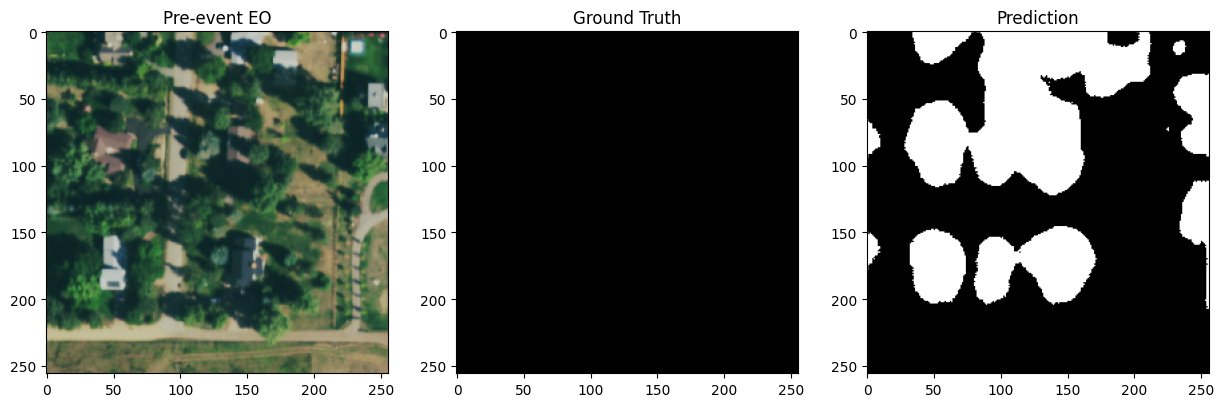

In [ ]:
import matplotlib.pyplot as plt

batch = next(iter(test_loader))

pre = batch['pre'].to(device)

post = batch['post'].to(device)

target = batch['target']

with torch.no_grad():

    pred = model(pre, post)

    pred = torch.sigmoid(pred)

    pred = (pred > 0.5).float()

pred = pred.cpu().squeeze().numpy()

pre_img = pre.cpu().squeeze().permute(1,2,0).numpy()

target = target.squeeze().numpy()

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)

plt.imshow(pre_img)

plt.title("Pre-event EO")

plt.subplot(1,3,2)

plt.imshow(target, cmap='gray')

plt.title("Ground Truth")

plt.subplot(1,3,3)

plt.imshow(pred, cmap='gray')

plt.title("Prediction")

plt.show()

In [ ]:
total_TP = 0
total_TN = 0
total_FP = 0
total_FN = 0

with torch.no_grad():
    for batch in test_loader:
        pre    = batch['pre'].to(device)
        post   = batch['post'].to(device)
        target = batch['target'].unsqueeze(1).to(device)
        nodata = batch['nodata'].unsqueeze(1).to(device)  # ✅ FIX: load nodata

        pred = model(pre, post)
        pred = torch.sigmoid(pred)
        pred = (pred > 0.5).float()

        # ✅ FIX: only evaluate on valid (non-nodata) pixels
        valid  = (nodata == 0)
        pred_v   = pred[valid]
        target_v = target[valid]

        total_TP += ((pred_v == 1) & (target_v == 1)).sum().item()
        total_TN += ((pred_v == 0) & (target_v == 0)).sum().item()
        total_FP += ((pred_v == 1) & (target_v == 0)).sum().item()
        total_FN += ((pred_v == 0) & (target_v == 1)).sum().item()

accuracy  = (total_TP + total_TN) / (total_TP + total_TN + total_FP + total_FN + 1e-8)
precision = total_TP / (total_TP + total_FP + 1e-8)
recall    = total_TP / (total_TP + total_FN + 1e-8)
f1        = 2 * precision * recall / (precision + recall + 1e-8)
iou       = total_TP / (total_TP + total_FP + total_FN + 1e-8)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1        : {f1:.4f}")
print(f"IoU       : {iou:.4f}")

Accuracy  : 0.7197
Precision : 0.0242
Recall    : 0.8012
F1        : 0.0470
IoU       : 0.0241
